In [ ]:
from google.colab import files
uploaded = files.upload()

Saving unlabelled_train_data_images (1).npy to unlabelled_train_data_images (1).npy


Loaded file: unlabelled_train_data_images (1).npy
Shape of Xtrain: (60000, 1, 28, 28)

Top 10 rows of the data:
   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
2      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
3      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
4      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
5      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
6      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
7      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
8      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
9      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

   pixel_8  pixel_9  ...  pixel_774  pix

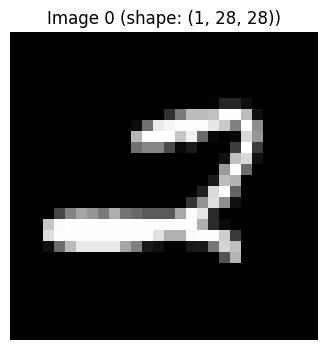

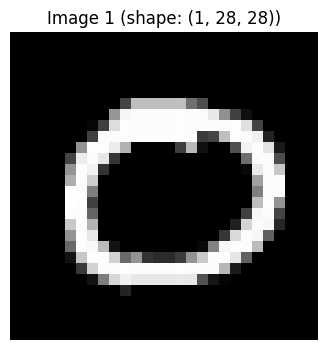

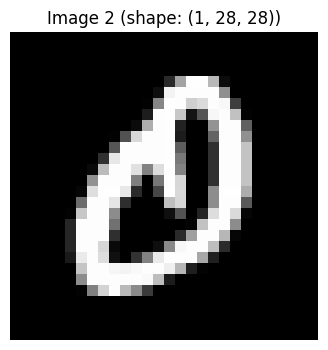

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load the data
filename = 'unlabelled_train_data_images (1).npy'
Xtrain   = np.load(filename)
print("Loaded file:", filename)
print("Shape of Xtrain:", Xtrain.shape)

# 2) Flatten each image into a row and build a DataFrame
X_flat = Xtrain.reshape(Xtrain.shape[0], -1)

# 3) Create column names for each pixel
col_names = [f'pixel_{i}' for i in range(X_flat.shape[1])]

# 4) Build DataFrame
df_flat = pd.DataFrame(X_flat, columns=col_names)

# 5) Show top 10 rows
print("\nTop 10 rows of the data:")
print(df_flat.head(10))

# 6) Show rows where at least 5 columns are non-zero
mask_5plus = (df_flat.ne(0).sum(axis=1) >= 5)
rows_5plus = df_flat[mask_5plus]
print(f"\nNumber of rows with ≥ 5 non-zero pixels: {rows_5plus.shape[0]}")
print("First 10 of those rows:")
print(rows_5plus.head(10))

# 7) Display the first 3 images
for i in range(3):
    img = Xtrain[i]
    plt.figure(figsize=(4, 4))

    # 2D grayscale
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')

    # 3D: channel-first (1, H, W) or channel-last (H, W, C)
    elif img.ndim == 3:
        # channel-first single channel
        if img.shape[0] == 1:
            plt.imshow(img.squeeze(0), cmap='gray')
        # channel-last (H, W, C)
        elif img.shape[2] in (1, 3, 4):
            if img.shape[2] == 1:
                plt.imshow(img.squeeze(-1), cmap='gray')
            else:
                plt.imshow(img)
        else:
            raise ValueError(f"Unsupported 3D image shape: {img.shape}")
    else:
        raise ValueError(f"Unsupported image shape: {img.shape}")

    plt.title(f"Image {i} (shape: {img.shape})")
    plt.axis('off')
    plt.show()





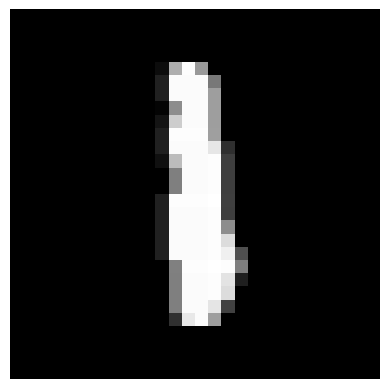

In [ ]:
import matplotlib.pyplot as plt
def view_img(df, idx):
    img = df[idx]
    img = img.squeeze()
    plt.imshow(img, cmap='gray')
    # plt.title(f'Label: {label}')
    plt.axis('off')
    plt.show()

view_img(Xtrain, 5)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Reshape each row into a 28x28 image and display them
Xtrain = Xtrain.reshape(-1, 28, 28)
Xtrain.shape
#Flattening each row
X_img_flat = Xtrain.reshape(len(Xtrain), -1)
print(X_img_flat.shape)

(60000, 784)


PCA-reduced shape for 10 comps: (60000, 10)
PCA-reduced shape for 50 comps: (60000, 50)
PCA-reduced shape for 100 comps: (60000, 100)


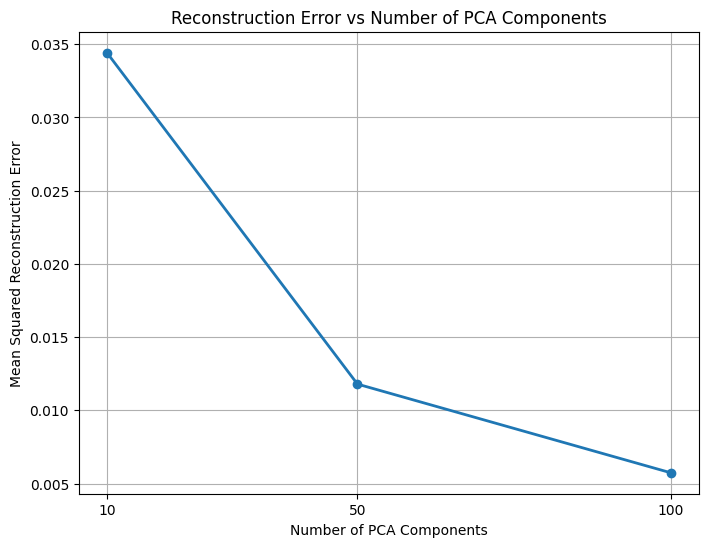

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# ── Prepare your image matrix (flattened) ─────────────────────────────────
# Assuming Xtrain is loaded with shape (N, 1, 28, 28):
X_img_flat = Xtrain.reshape(Xtrain.shape[0], -1)

# ── Dimensionality Reduction & Reconstruction ──────────────────────────────
components_list      = [10, 50, 100]
reconstructed_images = {}
errors               = {}

for n_components in components_list:
    pca = PCA(n_components=n_components, random_state=42)

    # 1) Fit & transform
    X_pca = pca.fit_transform(X_img_flat)
    print(f"PCA-reduced shape for {n_components} comps:", X_pca.shape)

    # 2) Inverse transform to reconstruct
    X_reconstructed = pca.inverse_transform(X_pca)

    # 3) Store results
    reconstructed_images[n_components] = X_reconstructed
    errors[n_components] = mean_squared_error(X_img_flat, X_reconstructed)

# ── Plot Reconstruction Error vs. # PCA Components ─────────────────────────
plt.figure(figsize=(8, 6))
plt.plot(components_list,
         [errors[n] for n in components_list],
         marker='o', linewidth=2)
plt.title('Reconstruction Error vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Mean Squared Reconstruction Error')
plt.xticks(components_list)
plt.grid(True)
plt.show()


The PCA‐reconstruction plot shows a clear trade‐off between the number of components (model complexity) and the fidelity of your reconstructed images (measured by mean squared error):

Steep initial drop

Going from 10 → 50 components cuts the MSE from ~0.035 down to ~0.012.

This means the first ~50 principal components capture the bulk of the image variance (most of the “information” in the data).

Diminishing returns

Increasing from 50 → 100 components further halves the error (from ~0.012 → ~0.006), but the incremental gain is smaller than the 10→50 jump.

Beyond 100 you’d see even smaller improvements per component.

Interpretation & guideline

If you need a very compact representation, 50 components give you a ~65% reduction in reconstruction error compared to just 10, at 5× fewer dimensions than the original 784.

If you can afford a bit more complexity (and want higher fidelity), 100 components bring the error down to under 0.006—recovering ~82% of the original variance in squared‐error terms.

Practical takeaway

For downstream tasks (clustering, classification), you might choose 50–100 components as a sweet spot: you retain most of the signal while cutting dimensionality by 8–16×.

Always balance your computational budget and the acceptable level of reconstruction error for your application.

In short, the plot confirms that most of the meaningful structure in your images is captured within the first few dozen principal components, and that you’ll face diminishing gains if you push far beyond ~50–100 dimensions.

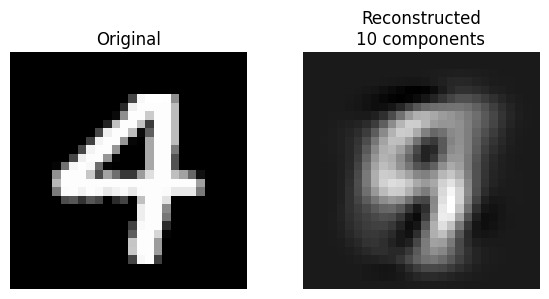

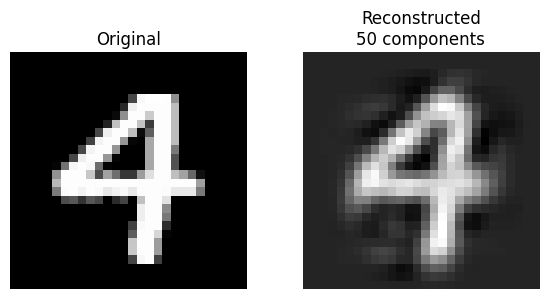

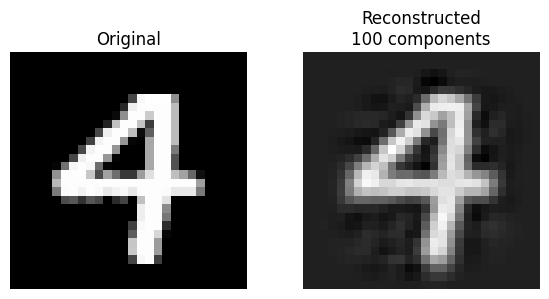

In [ ]:
def show_original_vs_reconstructed(original, reconstructed, index=0, n_components=10):
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))

    # Original Image
    axs[0].imshow(original[index].reshape(28, 28), cmap='gray')
    axs[0].set_title("Original")
    axs[0].axis('off')

    # Reconstructed Image
    axs[1].imshow(reconstructed[index].reshape(28, 28), cmap='gray')
    axs[1].set_title(f"Reconstructed\n{n_components} components")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

# Example:
# Visualize the original and Reconstructed image pairs - with different PCA components
for n in components_list:
    show_original_vs_reconstructed(X_img_flat, reconstructed_images[n], index=123, n_components=n)

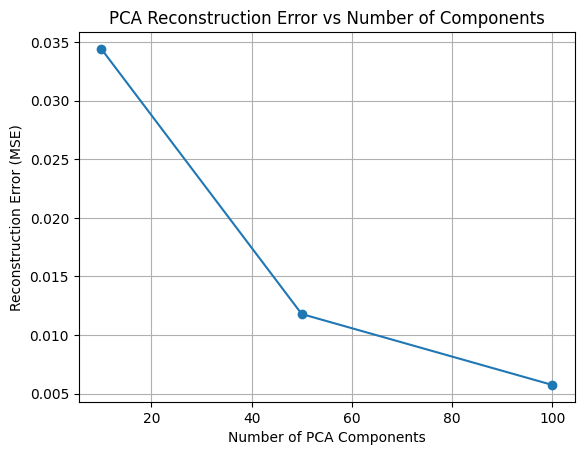

In [ ]:
 # Measure Reconstruction error, for different PCA components

plt.figure()
plt.plot(list(errors.keys()), list(errors.values()), marker='o')
plt.xlabel("Number of PCA Components")
plt.ylabel("Reconstruction Error (MSE)")
plt.title("PCA Reconstruction Error vs Number of Components")
plt.grid(True)
plt.show()

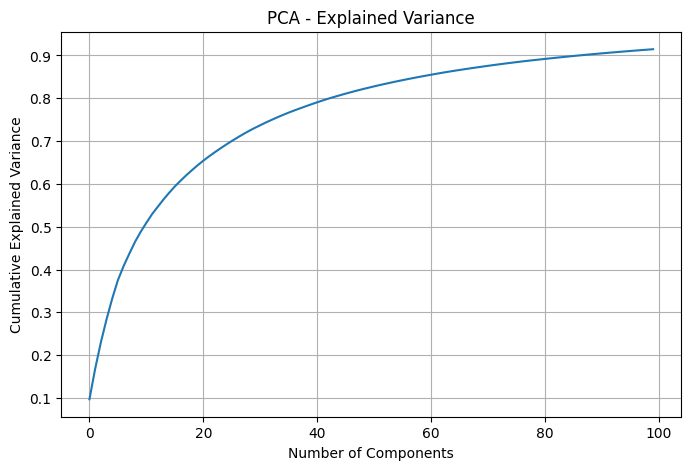

In [ ]:
# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X_img_flat)
# PCA
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

KMeans Silhouette Score: 0.07308487594127655


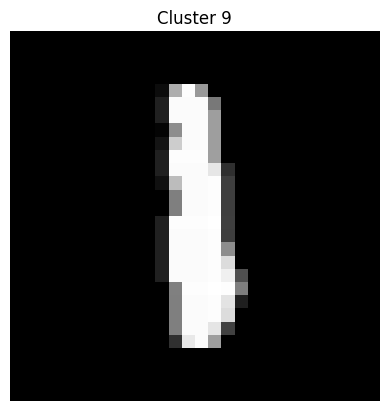

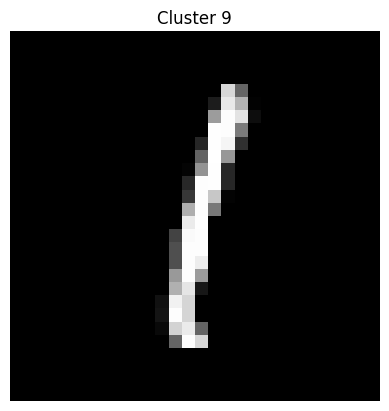

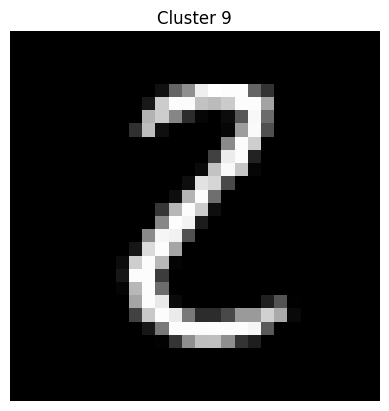

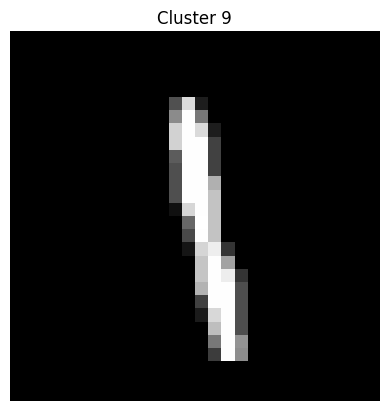

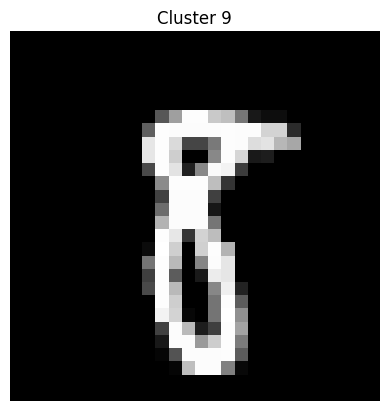

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
#KMeans Clustering (unsupervised labeling)
kmeans = KMeans(n_clusters=10, random_state=42)
y_clusters = kmeans.fit_predict(X_pca)
def view_img(img_array, label_array, cluster_num, num_samples=5):
    indices = np.where(label_array == cluster_num)[0][:num_samples]
    for i in indices:
        plt.imshow(Xtrain[i].squeeze(), cmap='gray')
        plt.title(f"Cluster {cluster_num}")
        plt.axis('off')
        plt.show()
kmeans_score = silhouette_score(X_pca, y_clusters)
print(f"KMeans Silhouette Score: {kmeans_score}")

#View images in cluster 9
view_img(Xtrain, y_clusters, cluster_num=9)

K-Means Silhouette Score: 0.068

GMM Silhouette Score: 0.021

=== K-Means Cluster 0 (4973 images) ===


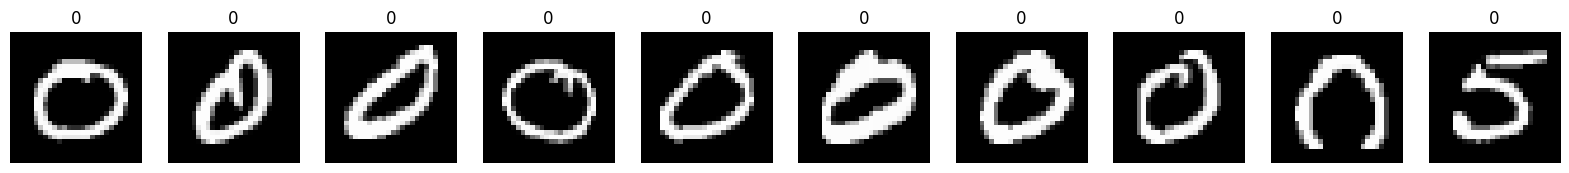

=== K-Means Cluster 1 (5497 images) ===


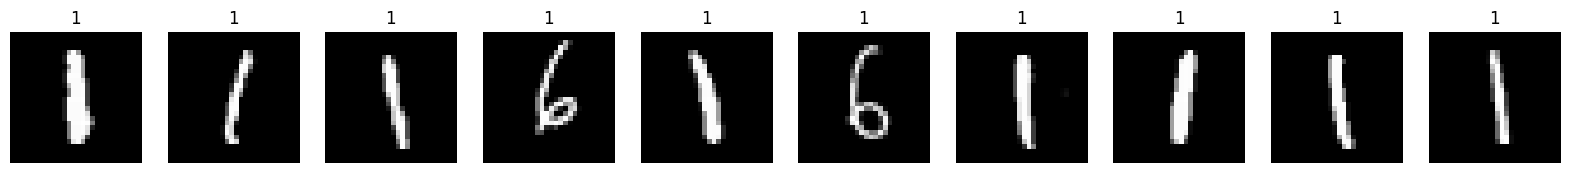

=== K-Means Cluster 2 (4636 images) ===


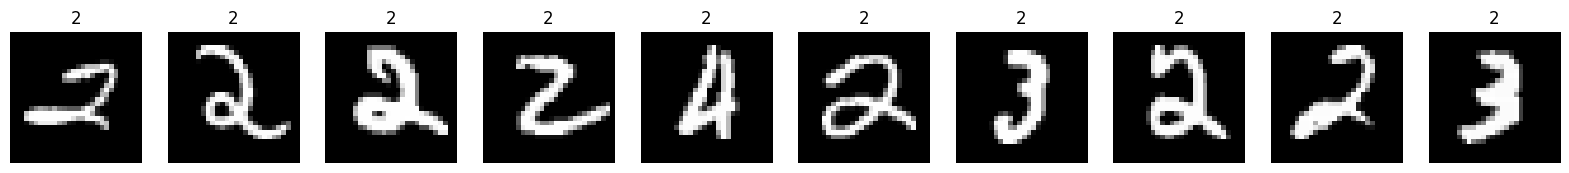

=== K-Means Cluster 3 (5276 images) ===


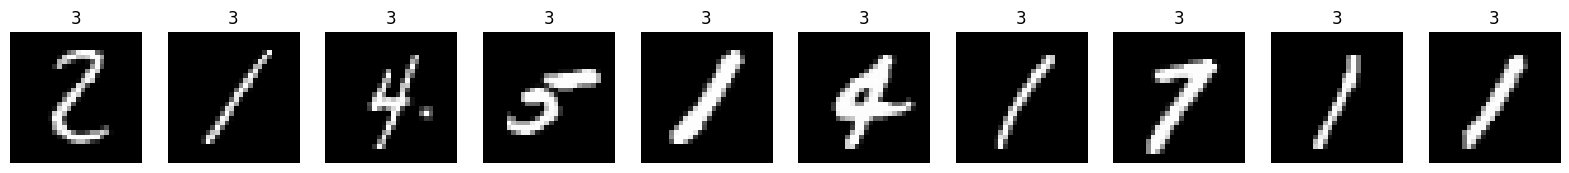

=== K-Means Cluster 4 (5422 images) ===


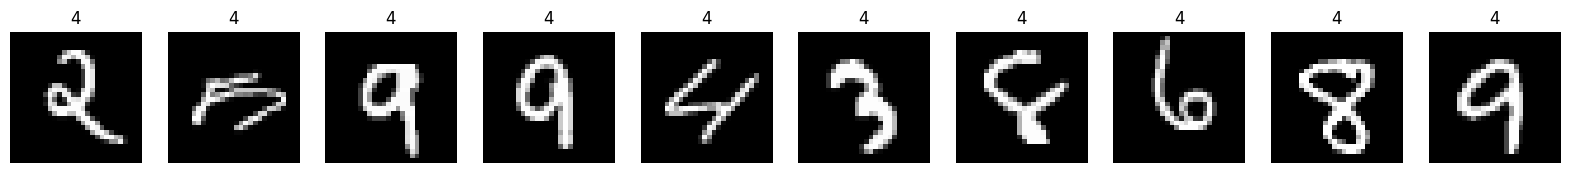

=== K-Means Cluster 5 (5401 images) ===


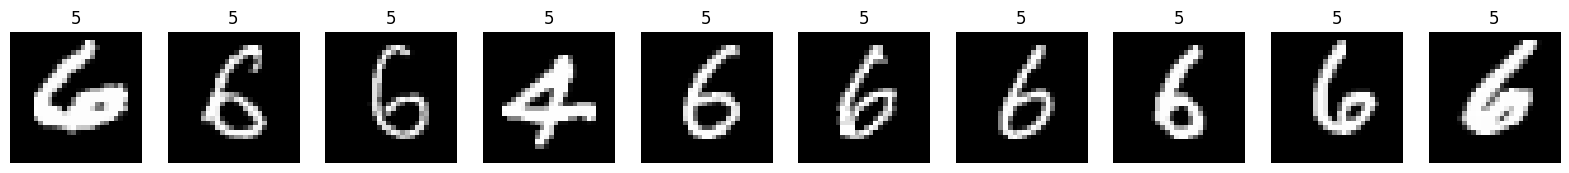

=== K-Means Cluster 6 (6688 images) ===


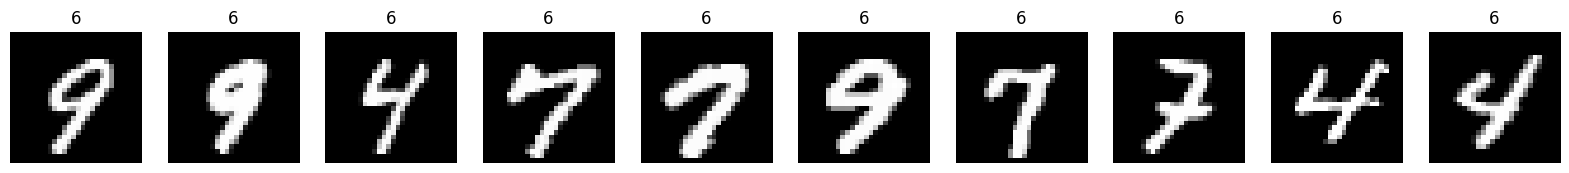

=== K-Means Cluster 7 (7058 images) ===


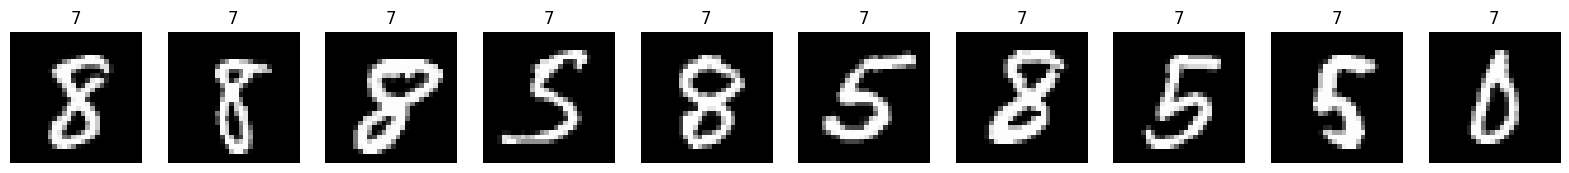

=== K-Means Cluster 8 (7810 images) ===


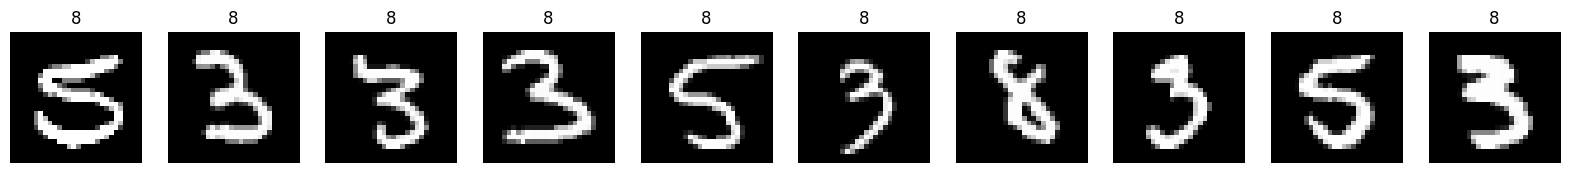

=== K-Means Cluster 9 (7239 images) ===


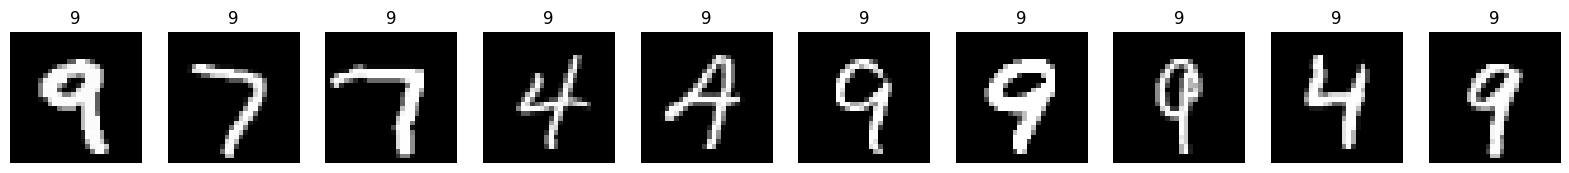

=== GMM Cluster 0 (4614 images) ===


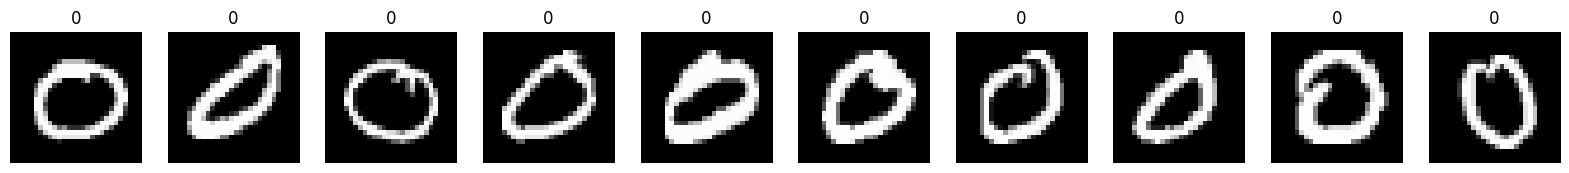

=== GMM Cluster 1 (3178 images) ===


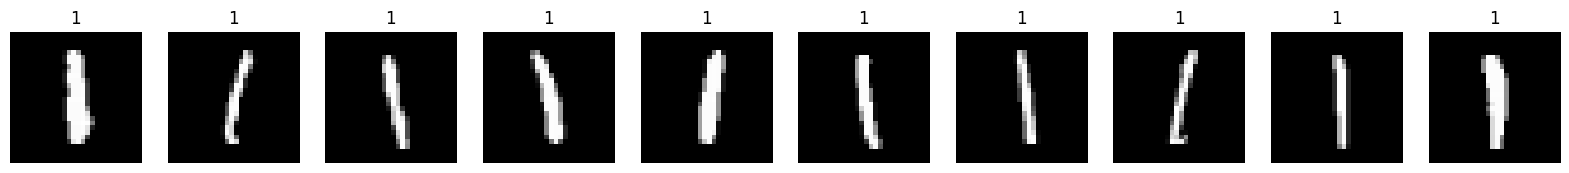

=== GMM Cluster 2 (5263 images) ===


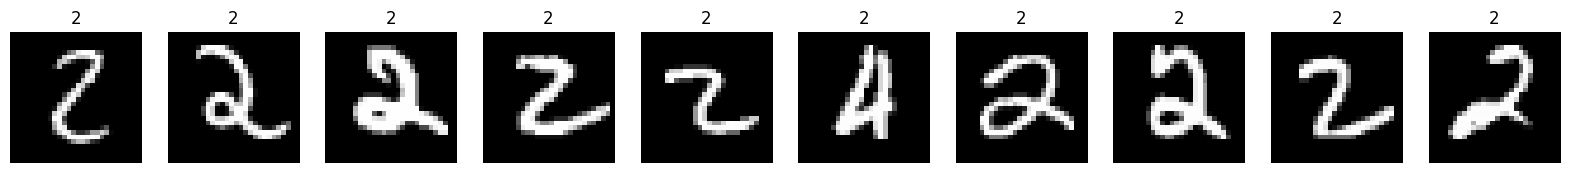

=== GMM Cluster 3 (2638 images) ===


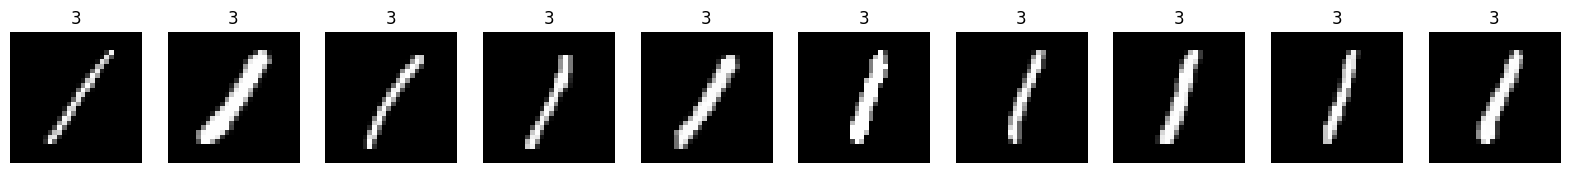

=== GMM Cluster 4 (6572 images) ===


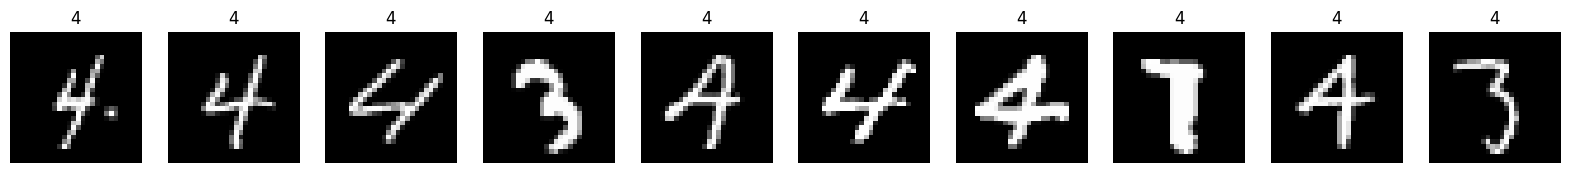

=== GMM Cluster 5 (4788 images) ===


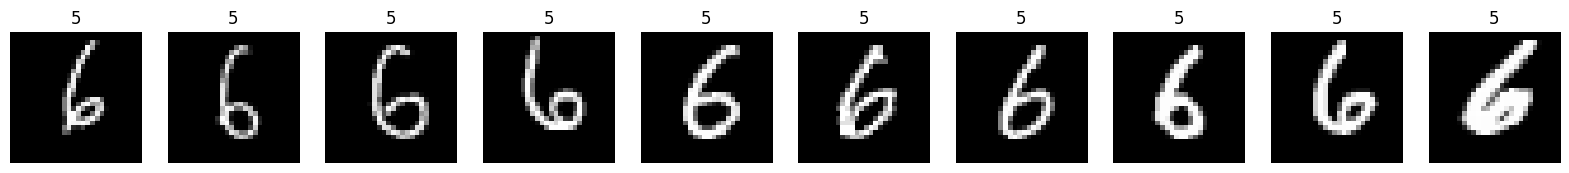

=== GMM Cluster 6 (5574 images) ===


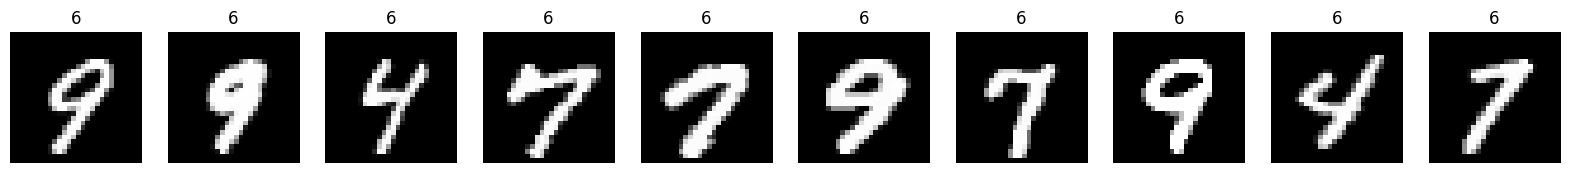

=== GMM Cluster 7 (9817 images) ===


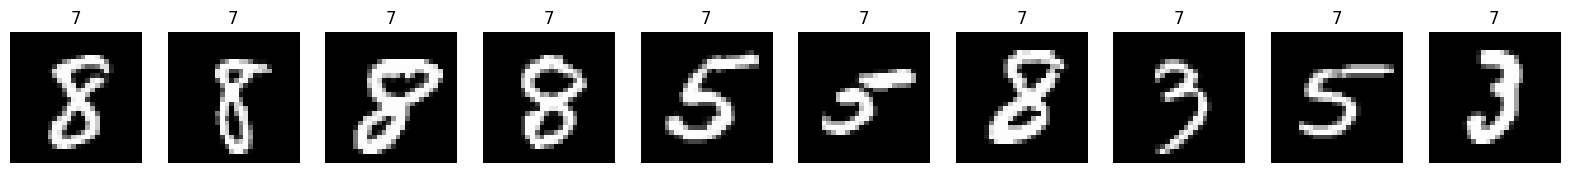

=== GMM Cluster 8 (12568 images) ===


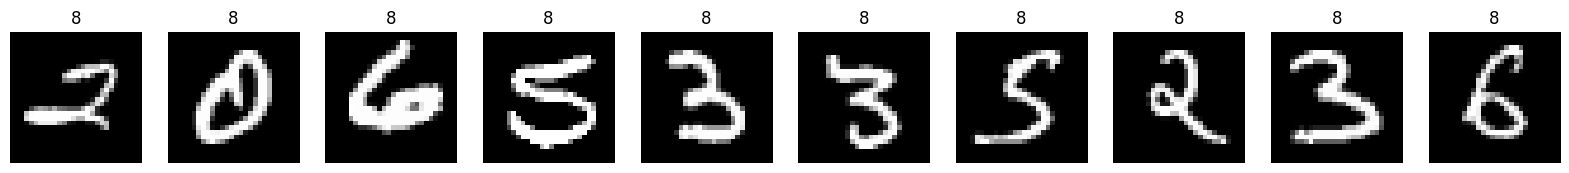

=== GMM Cluster 9 (4988 images) ===


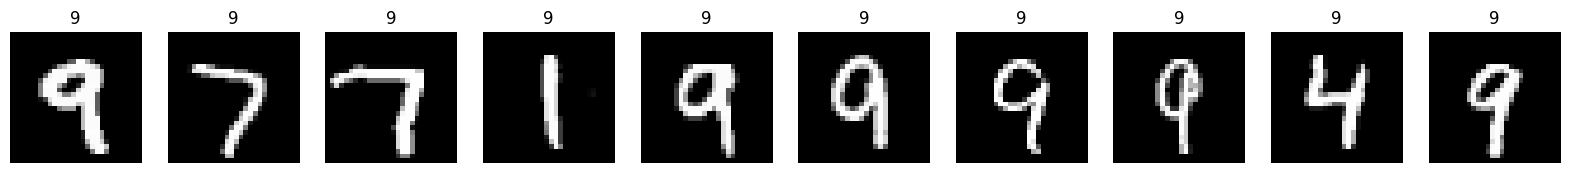

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster      import KMeans
from sklearn.mixture      import GaussianMixture
from sklearn.metrics      import silhouette_score

# 1) Fit K-Means
kmeans    = KMeans(n_clusters=10, random_state=42)
y_kmeans  = kmeans.fit_predict(X_pca)
score_km  = silhouette_score(X_pca, y_kmeans)
print(f"K-Means Silhouette Score: {score_km:.3f}\n")

# 2) Fit Gaussian Mixture
gmm       = GaussianMixture(n_components=10, random_state=42)
y_gmm     = gmm.fit_predict(X_pca)
score_gmm = silhouette_score(X_pca, y_gmm)
print(f"GMM Silhouette Score: {score_gmm:.3f}\n")

# 3) Helper to plot up to num_samples images for a given cluster
def view_images(img_array, label_array, cluster_num, num_samples=10):
    idxs = np.where(label_array == cluster_num)[0][:num_samples]
    if len(idxs) == 0:
        print(f"No images in cluster {cluster_num}")
        return
    fig, axes = plt.subplots(1, len(idxs), figsize=(2*len(idxs), 2))
    for ax, i in zip(axes, idxs):
        ax.imshow(img_array[i].squeeze(), cmap='gray')
        ax.set_title(f"{cluster_num}")
        ax.axis('off')
    plt.show()

# 4) Display clusters for K-Means
for cluster in range(10):
    print(f"=== K-Means Cluster {cluster} ({np.sum(y_kmeans==cluster)} images) ===")
    view_images(Xtrain, y_kmeans, cluster, num_samples=10)

# 5) Display clusters for GMM
for cluster in range(10):
    print(f"=== GMM Cluster {cluster} ({np.sum(y_gmm==cluster)} images) ===")
    view_images(Xtrain, y_gmm, cluster, num_samples=10)


We go ahead with k-means clustering

In [ ]:
import numpy as np
from sklearn.cluster       import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.svm           import SVC
from sklearn.metrics       import accuracy_score, classification_report

# ── 1) Fit K-Means to get your “labels” ──────────────────────────────────
kmeans     = KMeans(n_clusters=10, random_state=42)
y_clusters = kmeans.fit_predict(X_pca)   # now y_clusters is defined

# ── 2) Split into train/test ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_clusters,
    test_size=0.2,
    random_state=42,
    stratify=y_clusters
)

# ── 3) Helper to train & evaluate ───────────────────────────────────────
def train_and_evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    acc      = accuracy_score(y_test, y_pred)
    print(f"\n--- {model.__class__.__name__} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    return model

# ── 4) Train & evaluate each classifier ─────────────────────────────────
lr  = train_and_evaluate(LogisticRegression(max_iter=1000, random_state=42),
                         X_train, y_train, X_test, y_test)

rf  = train_and_evaluate(RandomForestClassifier(n_estimators=100, random_state=42),
                         X_train, y_train, X_test, y_test)

svm = train_and_evaluate(SVC(kernel='rbf', probability=True, random_state=42),
                         X_train, y_train, X_test, y_test)



--- LogisticRegression ---
Accuracy: 0.9894
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       995
           1       1.00      0.99      0.99      1099
           2       0.99      0.99      0.99       927
           3       0.99      0.99      0.99      1055
           4       0.99      0.99      0.99      1084
           5       0.99      0.99      0.99      1080
           6       0.99      0.99      0.99      1338
           7       0.99      0.99      0.99      1412
           8       1.00      0.99      0.99      1562
           9       0.99      0.99      0.99      1448

    accuracy                           0.99     12000
   macro avg       0.99      0.99      0.99     12000
weighted avg       0.99      0.99      0.99     12000


--- RandomForestClassifier ---
Accuracy: 0.9205
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       995
           1       0.96      0.89     